# Data set Loading


In [106]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import math, itertools, warnings
warnings.filterwarnings('ignore')
np.random.seed()

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(url)
print(df.shape) # expected (1338, 7)
print(df.dtypes)
print(df.head())

(1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


> # **Part#1**

# 1.1 The Normal Distribution - BMI

> ## sample mean (μ) and sample standard deviation (σ)

In [107]:
mean = round(df['bmi'].mean(),4)
std_dev = round(df['bmi'].std(),4)
print("Mean for BMI Column upto 4 Decimal Places is: ",mean)
print("Standard Deviation for BMI Column upto 4 Decimal Places is: ",std_dev)

Mean for BMI Column upto 4 Decimal Places is:  30.6634
Standard Deviation for BMI Column upto 4 Decimal Places is:  6.0982


> ## **Computing CDF**

In [108]:
under_weight_cdf = round(stats.norm.cdf(25,mean,std_dev),4)
temp_cdf = stats.norm.cdf(30,mean,std_dev)
over_weight_cdf = round(temp_cdf - under_weight_cdf,4)
obese_cdf = round(1 - temp_cdf,4)
print("Under Weight Preicted Probabilities are: ",under_weight_cdf)
print("Over Weight Preicted Probabilities are: ",over_weight_cdf)
print("Obese Preicted Probabilities are: ",obese_cdf)

Under Weight Preicted Probabilities are:  0.1765
Over Weight Preicted Probabilities are:  0.2802
Obese Preicted Probabilities are:  0.5433


> ## Actual Proportions

In [109]:
total = len(df)
under_weight_count = len(df[df['bmi'] < 25])
over_weight_count = len(df[(df['bmi'] >= 25) & (df['bmi'] < 30)])
obese_count = len(df[df['bmi'] >= 30])
under_weight_prop = round(under_weight_count / total,4)
over_weight_prop = round(over_weight_count / total,4)
obese_prop = round(obese_count / total,4)

print("Under Weight Proportion: ",under_weight_prop)
print("Over Weight Proportion: ",over_weight_prop)
print("Obese Proportion: ",obese_prop)

results_df = pd.DataFrame({
    'BMI Range': ['Underweight/Normal (<25)', 'Overweight (25-30)', 'Obese (>=30)'],
    'Actual Proportion': [under_weight_prop, over_weight_prop, obese_prop],
    'Predicted (Normal Model)': [under_weight_cdf, over_weight_cdf, obese_cdf]
})
print(results_df)

Under Weight Proportion:  0.1831
Over Weight Proportion:  0.2885
Obese Proportion:  0.5284
                  BMI Range  Actual Proportion  Predicted (Normal Model)
0  Underweight/Normal (<25)             0.1831                    0.1765
1        Overweight (25-30)             0.2885                    0.2802
2              Obese (>=30)             0.5284                    0.5433


> ## Histogram Plot

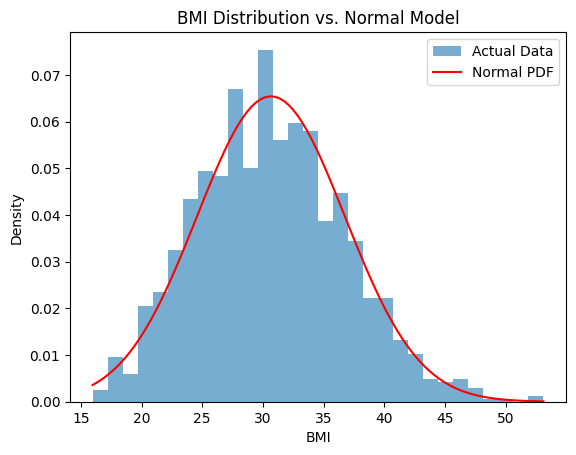

In [110]:
max_bmi = df['bmi'].max()
min_bmi = df['bmi'].min()
points = np.linspace(min_bmi,max_bmi,100)
pdf_value = stats.norm.pdf(points,mean,std_dev)
df['bmi'].plot.hist(bins=30,density=True,label = 'Actual Data',alpha = 0.6)
plt.plot(points,pdf_value,color='red',label = 'Normal PDF')
plt.title("BMI Distribution vs. Normal Model")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()

> ## Distribution Analysis of BMI

- **Central Peak:** The actual data shows a slightly higher concentration of policyholders around the BMI range of **30** than the Normal model predicts. This indicates that the average risk group is more tightly clustered than expected.

- **Right-Side Skew:** There is a noticeable **right tail** in the histogram at higher BMI values. Several bars between **BMI 45 and 55** rise above the red PDF line, suggesting that the data is slightly **right-skewed**.

- **Overall Fit:** Despite these minor deviations, the **Normal distribution** remains a strong approximation for the overall BMI distribution of policyholders.

> ## 5th and 95th percentile of BMI

In [111]:
fifth_percentile = round(np.percentile(df['bmi'],5),4)
nintyfifth_percentile = round(np.percentile(df['bmi'],95),4)
fifth_ppf = round(stats.norm.ppf(0.05,mean,std_dev),4)
nintyfifth_ppf = round(stats.norm.ppf(0.95,mean,std_dev),4)
print("5th Percentile of Actual Data: ",fifth_percentile)
print("95th Percentile of Actual Data: ",nintyfifth_percentile)
print("5th Percentile of Modal Data: ",fifth_ppf)
print("95th Percentile of Modal Data: ",nintyfifth_ppf)

5th Percentile of Actual Data:  21.256
95th Percentile of Actual Data:  41.106
5th Percentile of Modal Data:  20.6328
95th Percentile of Modal Data:  40.694


> ## Percentile Comparison and Interpretation

As discussed earlier, the BMI distribution is **right-skewed**, which means the upper end of the data contains more extreme values than a perfectly Normal (model) distribution would predict.

- The **95th percentile** of the actual data is **higher** than the 95th percentile of the model data.
- This indicates that the real dataset contains more individuals with **very high BMI values** than expected under a simple Normal distribution.

Similarly, the **5th percentile** may also differ slightly, but the most noticeable deviation appears in the upper tail due to the right skew.

This confirms that the real-world BMI distribution includes more **“heavier” individuals** than a simple mathematical bell curve can fully account for.

# 1.2 The Binomial Distribution - Smoker Rate

> ## Empirical Probability

In [112]:
smoker_count = len(df[df['smoker'] == 'yes'])
non_smoker_count = len(df[df['smoker'] == 'no'])
smoker_prob = round(smoker_count / total,4)
non_smoker_prob = round(non_smoker_count / total,4)
print("Smoker Empirical Probability is: ",smoker_prob)
print("Non-Smoker Empirical Probability is: ",non_smoker_prob)

Smoker Empirical Probability is:  0.2048
Non-Smoker Empirical Probability is:  0.7952


> ## Probability of Exactly K Smokers 

In [113]:
def binomial_pmf(n, k, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))
n = 50
k = [5,10,15,20]
p = smoker_prob
for i in range(4):
    result = binomial_pmf(n,k[i],p)
    print (f"Binomial Distribuition for k={k[i]} is=",round(result,4))


Binomial Distribuition for k=5 is= 0.0254
Binomial Distribuition for k=10 is= 0.1393
Binomial Distribuition for k=15 is= 0.0346
Binomial Distribuition for k=20 is= 0.0008


> ## **Compute P Using scipy.stats.binom.cdf**

In [114]:
k1 = 7
k2 = 20
Prob_fewer_than_8 = round(stats.binom.cdf(k1,n,smoker_prob),4) * 100
Prob_Greater_than_20 = round(1- stats.binom.cdf(k2,n,smoker_prob),4) * 100
print(f"Probability less than 8: {Prob_fewer_than_8}%",)
print(f"Probability Greater than 20: {Prob_Greater_than_20}%",)


Probability less than 8: 16.89%
Probability Greater than 20: 0.04%


> ## Risk Probability Interpretation

- **Low-Risk Probability:** There is a **16.89%** chance of having fewer than **8 smokers** in a random group of **50** policyholders. This suggests that nearly **1 in 6 groups** will have a relatively low smoking rate, which is favorable for the company’s overall risk profile.

- **High-Risk Probability:** The probability of having more than **20 smokers** in a group of **50** is extremely small, at only **0.04%**. This indicates that the likelihood of encountering an **over-saturated smoker group** is statistically negligible.

- **Conclusion:** Overall, the company’s risk remains well-centered around the expected average. Extreme cases with unusually high smoker concentration are highly unlikely to occur by chance, keeping the insurer’s exposure relatively stable and predictable.

> ## **Simulate 10,000 groups**

In [115]:
size = 10000
simulate_smokers = np.random.binomial(n,smoker_prob,size)
mean = smoker_prob * n
var = smoker_prob * n * non_smoker_prob
simulated_mean = np.mean(simulate_smokers)
simulated_var = np.var(simulate_smokers)
mean_error = (abs(mean - simulated_mean) / var ) * 100
var_error = (abs(var - simulated_var) / mean) * 100
print("Simulated Random Smokers are: ",simulate_smokers)
print("Theoretical Mean is: ",mean)
print("Theoretical Variance is: ",var)
print("Simulated Mean is: ",simulated_mean)
print("Simulated Variance is: ",simulated_var)
print(f"Mean Error is: {mean_error}%")
print(f"Variance Error is: {var_error}%")

Simulated Random Smokers are:  [ 9 11  8 ...  7 10 14]
Theoretical Mean is:  10.24
Theoretical Variance is:  8.142848
Simulated Mean is:  10.2066
Simulated Variance is:  8.202916440000001
Mean Error is: 0.41017589914487307%
Variance Error is: 0.5866058593750022%


> ## **Compute Separate Smoker Rates for Males and Females**

In [116]:
male_df = df[df['sex'] == "male"]
female_df = df[df['sex'] == "female"]
male_total = len(male_df)
female_total = len(female_df)
male_smokers_count = len(male_df[male_df['smoker'] == 'yes'])
female_smokers_count = len(female_df[female_df['smoker'] == 'yes'])
male_smokers_prob = male_smokers_count / male_total
female_smokers_prob = female_smokers_count / female_total
expected_male_smokers = round(n * male_smokers_prob,4)
expected_female_smokers = round(n * female_smokers_prob,4)
prob_female_zero_smokers = stats.binom.pmf(0,n,female_smokers_prob)
prob_male_zero_smokers = stats.binom.pmf(0,n,male_smokers_prob)
final_results = {
    'Sex': ['Male','Female'],
    'Expected Smokers': [expected_male_smokers,expected_female_smokers],
    'P(Zero Smokers)':[round(prob_male_zero_smokers,4),round(prob_female_zero_smokers,4)]
    
}
fdf = pd.DataFrame(final_results)
print("Expected Male Smokers are:",expected_male_smokers)
print("Expected Female Smokers are:" ,expected_female_smokers)
print("Probability of Male Zero Smokers: ",prob_male_zero_smokers)
print("Probability of Female Zero Smokers: ",prob_female_zero_smokers)
print(fdf)

Expected Male Smokers are: 11.7604
Expected Female Smokers are: 8.6858
Probability of Male Zero Smokers:  1.5038078848587274e-06
Probability of Female Zero Smokers:  7.185662988293868e-05
      Sex  Expected Smokers  P(Zero Smokers)
0    Male           11.7604           0.0000
1  Female            8.6858           0.0001



## **1.3  The Poisson Distribution - Number of Dependants**

> ## **Compute the mean (λ) and variance**

In [117]:
child_mean = round(df['children'].mean(),4)
child_var = round(df['children'].var(),4)
dispersion_ratio = round(child_mean / child_var,4)
print("Mean:",child_mean)
print("Variance:",child_var)
print("Dispersion Ratio: ",dispersion_ratio)

Mean: 1.0949
Variance: 1.4532
Dispersion Ratio:  0.7534


## Dispersion Ratio Interpretation

The calculated **dispersion ratio** is **0.7534**, which is reasonably close to **1**. In count-data analysis, a dispersion ratio near **1** indicates that the data follows the assumptions of a **Poisson distribution** fairly well.

This suggests that the Poisson model provides a **good fit** for the smoker count data, as the observed variance is close to the mean. Although the ratio is slightly below 1 (indicating mild under-dispersion), it is still close enough to support the conclusion that the **Poisson distribution is an appropriate model** for this dataset.

> ## Using Poisson PMF Formula

In [118]:
def poisson_pmf(k,lam):
    numerator = (lam ** k) * math.exp(-lam)
    denomerator = math.factorial(k)
    return numerator / denomerator
lam = child_mean
for x in range(5):
    print(f"Poisson PMF for X={x} using manual calculations is:",round(poisson_pmf(x,lam),4))
for x in range(5):
    print(f"Poisson PMF for X={x} using scipy.stats calculations is:",round(stats.poisson.pmf(x,lam),4))

Poisson PMF for X=0 using manual calculations is: 0.3346
Poisson PMF for X=1 using manual calculations is: 0.3663
Poisson PMF for X=2 using manual calculations is: 0.2005
Poisson PMF for X=3 using manual calculations is: 0.0732
Poisson PMF for X=4 using manual calculations is: 0.02
Poisson PMF for X=0 using scipy.stats calculations is: 0.3346
Poisson PMF for X=1 using scipy.stats calculations is: 0.3663
Poisson PMF for X=2 using scipy.stats calculations is: 0.2005
Poisson PMF for X=3 using scipy.stats calculations is: 0.0732
Poisson PMF for X=4 using scipy.stats calculations is: 0.02


> ## **Compare the Poisson-predicted probabilities**

In [119]:
total = len(df['children'])
count = df['children'].value_counts()
count_0 = count[0]
count_1 = count[1]
count_2 = count[2]
count_3 = count[3]
count_4 = count[4]
count_0_proportion = round(count_0 / total,4) 
count_1_proportion = round(count_1 / total,4) 
count_2_proportion = round(count_2 / total,4) 
count_3_proportion = round(count_3 / total,4) 
count_4_proportion = round(count_4 / total,4)
data = []
proportions = [count_0_proportion,count_1_proportion,count_2_proportion,count_3_proportion,count_4_proportion]
for x in range(5):
    pmf_val = round(stats.poisson.pmf(x, lam), 4) 
    data.append(pmf_val)
data_frame = {
    "Children" : [0,1,2,3,4],
    "Actual-Proportions %": proportions,
    "Poison-PMF %" : data,
    "Difference":  np.array(proportions) - np.array(data)
}
fdf = pd.DataFrame(data_frame)
print(fdf)

   Children  Actual-Proportions %  Poison-PMF %  Difference
0         0                0.4290        0.3346      0.0944
1         1                0.2422        0.3663     -0.1241
2         2                0.1794        0.2005     -0.0211
3         3                0.1173        0.0732      0.0441
4         4                0.0187        0.0200     -0.0013


> ## Poisson Model Fit Analysis

The largest difference between the **Poisson model** and the **actual data** occurs at **\(k = 1\)**, with a gap of **\(-0.1241\)**.  
This negative value indicates that the Poisson model **overestimates** the proportion of policyholders with exactly **one child** by more than **12%**.

In contrast, the model **underestimates** the proportion of policyholders with **no children** (**\(k = 0\)**).

These differences show that while the Poisson distribution captures the general pattern of family size counts, it does not perfectly represent the observed distribution. In particular, the mismatch at lower child counts suggests that the Poisson model is only an **approximate fit** for this dataset’s family-size behavior.

> ## **Compute P(children ≥ 3)**

In [120]:
p_poisson_model = round(1 - stats.poisson.cdf(2,lam),4)
count_greater_3 = len(df[df['children'] >= 3])
p_poisson_actual = round(count_greater_3 / total,4)
percentage_error = round(((p_poisson_actual-p_poisson_model) / p_poisson_actual) * 100,4)
print("Probability using Poisson Model: ",p_poisson_model)
print("Probability Using Actual Value: ",p_poisson_actual)
print(f"Percentage Error is:{percentage_error}%")

Probability using Poisson Model:  0.0986
Probability Using Actual Value:  0.1495
Percentage Error is:34.0468%


## Family Pricing Risk

The dataset shows that **200 policyholders** (**14.95%**) have **3 or more dependants**, indicating a segment that may require a dedicated **family pricing review**.

The **Poisson model** predicted only **9.86%** for this group, significantly **underestimating** the true proportion of high-dependant policyholders. This resulted in a substantial **34.05% percentage error**.

Because of this underestimation, the pricing team should place greater reliance on **actual historical data** rather than the Poisson model when evaluating high-dependant policies. Doing so will reduce the risk of underpricing and help better account for the true financial impact of larger-family policyholders.

# **Part#2**


# **2.1  Do Smokers Cost the Company Significantly More?**

> ## **Compute n, mean, median, and standard deviation**

In [121]:
smoker = df[df['smoker'] == 'yes']
non_smoker = df[df['smoker']=='no']
smoker_group = smoker['charges']
non_smoker_group = non_smoker['charges']
smoker_group_n = smoker_group.count()
non_smoker_group_n = non_smoker_group.count()
smoker_group_mean = round(smoker_group.mean(),4)
non_smoker_group_mean = round(non_smoker_group.mean(),4)
smoker_group_std_dev = round(smoker_group.std(),4)
non_smoker_group_std_dev = round(non_smoker_group.std(),4)
smoker_group_median = round(smoker_group.median(),4)
non_smoker_group_median = round(non_smoker_group.median(),4)
data = {
    "Smoker" : [smoker_group_n,smoker_group_mean,smoker_group_std_dev,smoker_group_median],
    "Non-Smoker" : [non_smoker_group_n,non_smoker_group_mean,non_smoker_group_std_dev,non_smoker_group_median]
}
summary = pd.DataFrame(data,index=['n','Mean','Standard Deviation','Median'])
print(summary)

                        Smoker  Non-Smoker
n                     274.0000   1064.0000
Mean                32050.2318   8434.2683
Standard Deviation  11541.5472   5993.7818
Median              34456.3485   7345.4053


## Cost Variability Summary

Non-smokers have a much lower standard deviation, meaning their insurance charges are more consistent and predictable.  
Smokers show much higher variability in charges, making them a less stable and more financially risky group.  
Since smoker charges are nearly four times higher on average, the hypothesis test is expected to show a statistically significant difference.

Text(0, 0.5, 'Charges')

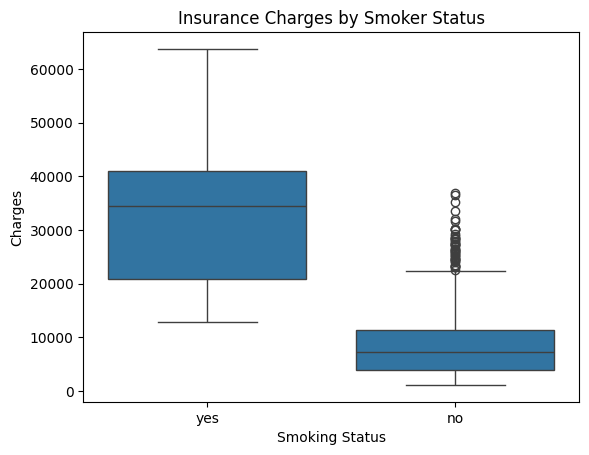

In [122]:
sns.boxplot(x='smoker',y='charges',data=df)
plt.title("Insurance Charges by Smoker Status")
plt.xlabel('Smoking Status')
plt.ylabel('Charges')

> ## Analysis of the Plot

  * The smoker box is much taller than the non-smoker box, showing that smoker charges have far greater spread and variance.  
  *  Several outliers appear above the non-smoker group, indicating that some non-smokers still have unusually high charges.  
  *  The smoker median is around 35,000 while the non-smoker median is below 10,000, with no meaningful overlap between the two groups.

> ## Levene’s Test 

In [123]:
stat,p_value  = stats.levene(smoker_group,non_smoker_group)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

Statisitc value:  332.6135
P-Value:  1.5593284881803726e-66


> ## Levene’s Test Interpretation

The p-value from **Levene’s Test** is well below **0.05**, so the null hypothesis of equal variance is rejected.  
This confirms that the spread of insurance charges for smokers is significantly different from that of non-smokers, supporting the box plot observation.  
Because the variances are unequal, **Welch’s T-test** (**equal_var = False**) should be used to compare the group means.

> ## scipy.stats.ttest_ind 

In [124]:
stat,p_value = stats.ttest_ind(smoker_group,non_smoker_group,equal_var=False)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

Statisitc value:  32.7519
P-Value:  5.88946444671698e-103


## Welch’s T-Test Interpretation

The p-value from **Welch’s T-Test** is well below **0.05**, so the null hypothesis of equal means is rejected.  
This confirms that the average insurance charges for smokers are significantly higher than those for non-smokers.  
The difference is both statistically significant and financially substantial, with smokers paying far more on average.

> ## **Confidence Interval**

In [125]:
mean_diff = smoker_group_mean - non_smoker_group_mean
smoker_group_var = smoker_group.var()
non_smoker_group_var = non_smoker_group.var()
standard_error = np.sqrt(smoker_group_var/smoker_group_n + non_smoker_group_var/smoker_group_n)
error_margin = 1.96 * standard_error
lower_bound = mean_diff - error_margin
upper_bound = mean_diff + error_margin
print("Standard Error is:",round(standard_error,4))
print("Error Margin:",round(error_margin,4))
print("Lower Bound: ",round(lower_bound,4))
print("Upper Bound: ",round(upper_bound,4))

Standard Error is: 785.6671
Error Margin: 1539.9075
Lower Bound:  22076.056
Upper Bound:  25155.871


>  ## **Confidence Interval Interpretation**
The company can expect smokers to cost between **$22,076.06** and **$25,155.87** more per year than non-smokers, with **95% confidence**.

> ## **Compute Cohen's d.**

In [126]:
pooled_varience = (((smoker_group_n - 1) * smoker_group_var) + ((non_smoker_group_n - 1) * non_smoker_group_var)) / (smoker_group_n + non_smoker_group_n - 2) 
pooled_std_dev = np.sqrt(pooled_varience)
cohen_d = mean_diff / pooled_std_dev
print("Cohen's d:",round(cohen_d,4))

Cohen's d: 3.1613


## Effect Size Interpretation

This is an **extremely large** effect size, showing that the difference is highly practically significant.  
The two groups are financially very distinct, with smokers creating a much greater cost impact on the company.  
A separate pricing tier is clearly justified, as charging both groups the same premium would ignore a major and statistically robust cost difference.

In [127]:
stat, p_value = stats.mannwhitneyu(smoker_group, non_smoker_group, alternative='two-sided')
print("U-Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

U-Statisitc value:  284133.0
P-Value:  5.270233444503571e-130


## Mann-Whitney U Test Interpretation

The Mann-Whitney U test returned a statistic of **284,133** and a p-value of **(5.27 times 10^-130)**, confirming a highly significant difference between the two groups.  
This strongly supports the T-test result and confirms that smokers consistently have higher insurance charges than non-smokers across the dataset.

# **2.2  Is There a Statistically Significant Difference Between Male and Female Charges?**

> ## Extract charges for males and females

In [128]:
male = df[df['sex'] == 'male']
female = df[df['sex'] == 'female']
male_group = male['charges']
female_group = female['charges']
male_n = male_group.count()
male_mean = round(male_group.mean(),4)
male_std_dev = round(male_group.std(),4)
female_n = female_group.count()
female_mean = round(female_group.mean(),4)
female_std_dev = round(female_group.std(),4)
print("Male n:",male_n)
print("Male Mean:",male_mean)
print("Male Standard Deviation:",male_std_dev)
print("Female n:",female_n)
print("Female Mean:",female_mean)
print("Female Standard Deviation:",female_std_dev)


Male n: 676
Male Mean: 13956.7512
Male Standard Deviation: 12971.0259
Female n: 662
Female Mean: 12569.5788
Female Standard Deviation: 11128.7038


## Gender-Based Charge Analysis

There is an average difference of about **$1,387** between male and female insurance charges.  
Male charges also have a higher standard deviation, indicating greater variability compared to females.  
Although males have a slightly higher mean, the gap is much smaller than the smoker analysis, so a T-test is needed to determine whether the difference is statistically significant.

> ## Levene’s Test Gender Basis

In [129]:
stat,p_value  = stats.levene(male_group,female_group)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",round(p_value,4))

Statisitc value:  9.9093
P-Value:  0.0017


## Levene’s Test Interpretation

The Levene’s test produced a p-value of **0.0017**, which is below the **0.05** significance level, so the assumption of equal variances is rejected.  
This indicates that the spread of insurance charges differs significantly between males and females.  
Therefore, **Welch’s T-test** (**equal_var = False**) should be used to compare the group means accurately.

> ## **Welch’s T-test**

In [130]:
res = stat,p_value = stats.ttest_ind(male_group,female_group,equal_var=False)
degree_of_freedom = round(res.df,4)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",round(p_value,4))
print("Degree of Freedom:",degree_of_freedom)

Statisitc value:  2.1009
P-Value:  0.0358
Degree of Freedom: 1313.3603


## Welch’s T-Test Interpretation

Since the p-value (**0.0358**) is below **0.05**, the null hypothesis is rejected, indicating a statistically significant difference between male and female insurance charges.  
The positive T-statistic confirms that males have higher average charges than females in this dataset.  
However, the effect is much weaker compared to the smoker analysis, where the statistical evidence was far stronger.

> ## **Confidence Interval Gender Basis**

In [131]:
mean_diff = male_mean - female_mean
male_var = male_group.var()
female_var = female_group.var()
standard_error = np.sqrt(male_var/male_n + female_var/female_n)
error_margin = 1.96 * standard_error
lower_bound = mean_diff - error_margin
upper_bound = mean_diff + error_margin
print("Standard Error is:",round(standard_error,4))
print("Error Margin:",round(error_margin,4))
print("Lower Bound: ",round(lower_bound,4))
print("Upper Bound: ",round(upper_bound,4))

Standard Error is: 660.2791
Error Margin: 1294.147
Lower Bound:  93.0254
Upper Bound:  2681.3194


## Confidence Interval Interpretation

At **(alpha = 0.05\)**, the null hypothesis is rejected because the **95% confidence interval** for the mean difference is **[$93.03,\ $2,681.32]**, which does not include zero.  
This confirms that males have significantly higher insurance charges than females on average.  
However, the relatively small lower bound suggests that the practical impact of gender is much weaker than the impact of smoking status.

> ## **Compute Cohen's d. Gender Basis**

In [132]:
pooled_varience = (((male_n - 1) * male_var) + ((female_n - 1) * female_var)) / (male_n + female_n - 2) 
pooled_std_dev = np.sqrt(pooled_varience)
cohen_d = mean_diff / pooled_std_dev
print("Cohen's d:",round(cohen_d,4))

Cohen's d: 0.1147


## Cohen's d Interpretation

Although the gender-based difference in charges is statistically significant, it should not be treated as a primary pricing factor.  
The computed **Cohen’s \(d = 0.1147\)** indicates a very small effect size, meaning the practical difference between males and females is minimal.  
Additionally, the confidence interval lower bound of only **$93.03** suggests that the guaranteed cost difference is too small to justify a separate pricing tier.

# **2.3  Has BMI Increased With Age? - A Correlation-Adjacent Test**

> ## **Under_40 and Over_40 Groups**

In [133]:
under_40 = df[df['age'] < 40]
over_40 = df[df['age'] >= 40]
under_40_group = under_40['bmi']
over_40_group = over_40['bmi']
under_40_n = under_40_group.count()
under_40_mean = under_40_group.mean()
under_40_std_dev = under_40_group.std()
under_40_var = under_40_group.var()
under_40_median = under_40_group.median()

over_40_n = over_40_group.count()
over_40_mean = over_40_group.mean()
over_40_std_dev = over_40_group.std()
over_40_var = over_40_group.var()
over_40_median = over_40_group.median()

print("Under 40 n:",under_40_n)
print("Under 40 Mean:",round(under_40_mean,4))
print("Under 40 Median:",round(under_40_median,4))
print("Under 40 Standard Deviation:",round(under_40_std_dev,4))
print("Under 40 Variance:",round(under_40_var,4))


print("Over 40 n:",over_40_n)
print("Over 40 Mean:",round(over_40_mean,4))
print("Over 40 Median:",round(over_40_median,4))
print("Over 40 Standard Deviation:",round(over_40_std_dev,4))
print("Over 40 Variance:",round(over_40_var,4))

Under 40 n: 674
Under 40 Mean: 30.0749
Under 40 Median: 29.805
Under 40 Standard Deviation: 6.243
Under 40 Variance: 38.9752
Over 40 n: 664
Over 40 Mean: 31.2607
Over 40 Median: 31.16
Over 40 Standard Deviation: 5.8924
Over 40 Variance: 34.7203


## BMI Comparison by Age Group

The **Under 40** group has an average BMI of **30.07** with a higher variance (**38.98**), indicating greater diversity in body types.  
The **Over 40** group shows a slightly higher average BMI of **31.26** with a lower variance (**34.72**), suggesting BMI becomes more concentrated with age.  
Overall, BMI tends to increase slightly and become more consistent among older individuals.

> ## Levene’s Test BMI Basis

In [134]:
stat,p_value  = stats.levene(under_40_group,over_40_group)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",round(p_value,4))

Statisitc value:  0.5806
P-Value:  0.4462


## Levene’s Test Interpretation

The Levene’s test produced a p-value of **0.4462**, which is greater than **0.05**, so the assumption of equal variances is satisfied.  
This indicates that the BMI variances between the two age groups are statistically similar.  
Therefore, a standard **Student’s T-test** (**equal_var = True**) should be used to compare the mean BMIs.

> ## **Welch’s T-test BMI Basis** 

In [135]:
res = stat,p_value = stats.ttest_ind(over_40_group,under_40_group,equal_var=True)
degree_of_freedom = round(res.df,4)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",round(p_value,4))
print("Degree of Freedom:",degree_of_freedom)

Statisitc value:  3.5718
P-Value:  0.0004
Degree of Freedom: 1336.0


## T-Test Interpretation BMI Basis

The T-test produced a p-value of **0.0004**, which is below **0.05**, so the null hypothesis is rejected.  
This confirms a statistically significant difference in BMI between the two age groups.  
The positive T-statistic indicates that individuals over 40 have a higher average BMI than those under 40.

> ## **Confidence Interval and Cohen's d BMI Basis**

In [136]:
mean_diff = over_40_mean - under_40_mean
standard_error = np.sqrt(over_40_var/over_40_n + under_40_var/under_40_n)
error_margin = 1.96 * standard_error
lower_bound = mean_diff - error_margin
upper_bound = mean_diff + error_margin
pooled_varience = (((over_40_n - 1) * over_40_var) + ((under_40_n - 1) * under_40_var)) / (over_40_n + under_40_n - 2) 
pooled_std_dev = np.sqrt(pooled_varience)
cohen_d = mean_diff / pooled_std_dev
print("Standard Error is:",round(standard_error,4))
print("Error Margin:",round(error_margin,4))
print("Lower Bound: ",round(lower_bound,4))
print("Upper Bound: ",round(upper_bound,4))
print("Cohen's d:",round(cohen_d,4))

Standard Error is: 0.3318
Error Margin: 0.6504
Lower Bound:  0.5354
Upper Bound:  1.8362
Cohen's d: 0.1953


## Confidence Interval and Effect Size Interpretation

The **95% confidence interval ([0.535, 1.836])** does not include zero, confirming a statistically significant BMI difference between the age groups.  
Individuals over 40 have higher average BMIs than those under 40.  
However, the **Cohen’s \(d \approx 0.19\)** indicates a negligible practical effect, as the difference is less than two BMI points.

> ## **Pearson's correlation coefficient**

In [137]:
r, p = stats.pearsonr(df['age'], df['bmi'])
print("Pearson's correlation coefficient r:",round(r,4))
print("P-Value:",p)

Pearson's correlation coefficient r: 0.1093
P-Value: 6.194289065049117e-05


## T-Test vs Correlation Interpretation

Both the T-test and Pearson correlation show a statistically significant positive relationship between age and BMI (**p < 0.05**), confirming that BMI tends to increase with age.  
The T-test captures differences in mean BMI between age groups, while the correlation measures the overall linear trend across all ages.  
Both methods agree on a real but weak upward relationship, and would only differ if the relationship were non-linear.

# **2.4  Regional Pricing - Multiple Comparisons**

> ## **Mean and standard deviation of Regions**

In [138]:
mean = df.groupby('region')['charges'].mean().sort_values(ascending=False)
std_dev = df.groupby('region')['charges'].std().sort_values(ascending=False)
results = {
    "Mean" : mean,
    "Standard Deviation" : std_dev
}
results_df = pd.DataFrame(results).sort_values(by="Mean", ascending=False)
print(results)

{'Mean': region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64, 'Standard Deviation': region
southeast    13971.098589
southwest    11557.179101
northeast    11255.803066
northwest    11072.276928
Name: charges, dtype: float64}


> ## **C(4,2) = 6 pairwise two-sample t-tests comparing**

In [139]:
regions = df['region'].unique()
results = []
for region_1,region_2 in itertools.combinations(regions,2):
    group_1 = df[df['region'] == region_1]['charges']
    group_2 = df[df['region'] == region_2]['charges']
    stat, p_val = stats.ttest_ind(group_1, group_2,equal_var=False)
    results.append({
        'pair': f"{region_1} vs {region_2}",
        't_stat': stat,
        'p_value': p_val
    })

results_df = pd.DataFrame(results).sort_values(by='p_value',ascending=False)
print(results_df.to_string(index=False))

                  pair    t_stat  p_value
southwest vs northwest -0.079565 0.936608
northwest vs northeast -1.128139 0.259679
southwest vs northeast -1.183014 0.237238
southeast vs northeast  1.380165 0.167990
southeast vs northwest  2.425150 0.015562
southwest vs southeast -2.454116 0.014372


> ## **Bonferroni Correction**

In [140]:
results = []
for region_1,region_2 in itertools.combinations(regions,2):
    group_1 = df[df['region'] == region_1]['charges']
    group_2 = df[df['region'] == region_2]['charges']
    stat, p_val = stats.ttest_ind(group_1, group_2,equal_var=False)
    results.append({
        'pair': f"{region_1} vs {region_2}",
        't_stat': stat,
        'p_value': p_val,
        'p_bonf': min(p_val * 6, 1.0) 
    })
results_df = pd.DataFrame(results).sort_values(by='p_value',ascending=False)
print(results_df.to_string(index=False))

                  pair    t_stat  p_value   p_bonf
southwest vs northwest -0.079565 0.936608 1.000000
northwest vs northeast -1.128139 0.259679 1.000000
southwest vs northeast -1.183014 0.237238 1.000000
southeast vs northeast  1.380165 0.167990 1.000000
southeast vs northwest  2.425150 0.015562 0.093374
southwest vs southeast -2.454116 0.014372 0.086230


## Bonferroni Correction Interpretation

Before the Bonferroni correction, the Southeast showed significant differences compared to the Northwest (**p = 0.0156**) and Southwest (**p = 0.0144**).  
After adjusting for multiple comparisons, all corrected p-values exceeded **0.05**, meaning no regional differences remained statistically significant.  
This suggests that the earlier differences were likely caused by random chance rather than a consistent underlying regional trend.

> ## **Family-Wise Error Rate**

In [141]:
alpha = 0.05
num_tests = 6
fwer = 1 - (1 - alpha)**num_tests

print("Family-wise error rate (FWER) without correction:",round(fwer,4))

Family-wise error rate (FWER) without correction: 0.2649


## Family-Wise Error Rate Interpretation

The calculated **FWER of 0.2649** means there is a **26.5%** chance of making at least one Type I error when performing six separate tests at the 5% significance level.  
This happens because each additional test increases the likelihood of falsely detecting a significant result due to random variation.  
The **Bonferroni correction** is therefore necessary to reduce the overall error risk back to the acceptable **0.05** level.

> ## **Compute a 95% Confidence Interval**

In [142]:
region_stats = df.groupby('region')['charges'].agg(['mean', 'std', 'count'])
region_stats['SEM'] = region_stats['std'] / np.sqrt(region_stats['count'])
region_stats['CI_lower'], region_stats['CI_upper'] = stats.t.interval(
    0.95, 
    df=region_stats['count'] - 1, 
    loc=region_stats['mean'], 
    scale=region_stats['SEM']
)
region_stats['CI(Difference)'] = region_stats['CI_upper'] - region_stats['CI_lower']
print(region_stats.to_string(index=False))

        mean          std  count        SEM     CI_lower     CI_upper  CI(Difference)
13406.384516 11255.803066    324 625.322393 12176.165507 14636.603525     2460.438018
12417.575374 11072.276928    325 614.179418 11209.292360 13625.858388     2416.566028
14735.411438 13971.098589    364 732.284540 13295.358775 16175.464101     2880.105326
12346.937377 11557.179101    325 641.076951 11085.738503 13608.136252     2522.397749


## Confidence Interval Width Interpretation

The Southeast region has the widest confidence interval (**2880.11**) because it also has the highest standard deviation, indicating greater variability in medical charges.  
Although the region has a large sample size, the presence of extreme high-cost cases increases the margin of error.  
As a result, the estimate of the Southeast’s average medical charges is the least precise among all regions.

> ## **Plot the Four Regional CIs**

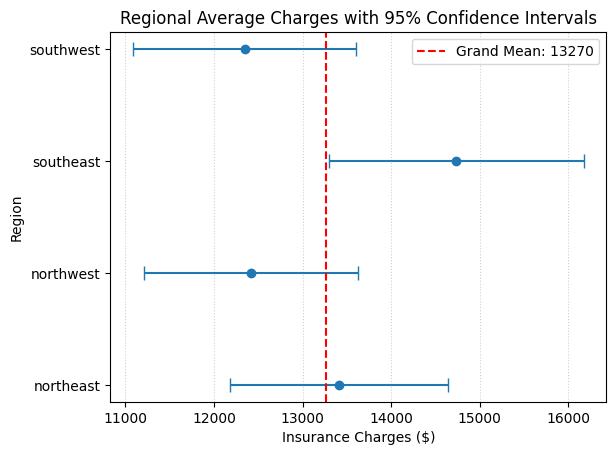

In [143]:
lower_error = region_stats['mean'] - region_stats['CI_lower']
upper_error = region_stats['CI_upper'] - region_stats['mean']
plt.errorbar(x=region_stats['mean'], 
             y=region_stats.index, 
             xerr=[lower_error, upper_error], 
             fmt='o', 
             capsize=5)
grand_mean = df['charges'].mean()
plt.axvline(grand_mean, color='red', linestyle='--', label=f'Grand Mean: {round(grand_mean)}')
plt.xlabel('Insurance Charges ($)')
plt.ylabel('Region')
plt.title('Regional Average Charges with 95% Confidence Intervals')
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6)

## Regional Confidence Interval Interpretation

The confidence intervals for all four regions show substantial visual overlap, especially between the Southeast and Northeast.  
Because the intervals share many common values, there is insufficient statistical evidence to confirm meaningful regional cost differences.  
This supports the Bonferroni results and suggests that geography is not a statistically significant factor in this analysis.

>  # **Part 3 - Your Own Investigation**

> ## **3.1  Open-Ended Question from the Manager**

> # **Male Ploicy Holder Analysis**

> ## **Male Smokers Extraction**

In [144]:
male_gender = df[df['sex'] == 'male']
male_smoker = male_gender[male_gender['smoker'] == 'yes']
male_non_smoker = male_gender[male_gender['smoker'] == 'no']
male_smoker_charges = male_smoker['charges']
male_non_smoker_charges = male_non_smoker['charges']

> ## **Levene's Test Male Smokers Basis**

In [145]:
stat,p_value  = stats.levene(male_smoker_charges,male_non_smoker_charges)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

Statisitc value:  135.1674
P-Value:  1.3253712426389895e-28


> ## **Welch’s T-Test Male Smoker Basis**

In [168]:
res = stat,p_value_male = stats.ttest_ind(male_smoker_charges,male_non_smoker_charges,equal_var=False)
degree_of_freedom = round(res.df,4)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value_male)
print("Degree of Freedom:",degree_of_freedom)

Statisitc value:  26.9593
P-Value:  4.027421672560831e-66
Degree of Freedom: 185.7699


> ## **Confidence Interval and Cohen's d Male Policy**

In [169]:
male_smoker_mean = male_smoker_charges.mean()
male_non_smoker_mean = male_non_smoker_charges.mean()
mean_diff = male_smoker_mean - male_non_smoker_mean
male_smoker_var = male_smoker_charges.var()
male_non_smoker_var = male_non_smoker_charges.var()
male_smoker_n = male_smoker_charges.count()
male_non_smoker_n = male_non_smoker_charges.count()
standard_error = np.sqrt(male_smoker_var/male_smoker_n + male_non_smoker_var/male_non_smoker_n)
error_margin = 1.96 * standard_error
lower_bound = mean_diff - error_margin
upper_bound = mean_diff + error_margin
pooled_varience = (((male_smoker_n - 1) * male_smoker_var) + ((male_non_smoker_n - 1) * male_non_smoker_var)) / (male_smoker_n + male_non_smoker_n - 2) 
pooled_std_dev = np.sqrt(pooled_varience)
cohen_d = mean_diff / pooled_std_dev
print("Standard Error is:",round(standard_error,4))
print("Error Margin:",round(error_margin,4))
print("Lower Bound: ",round(lower_bound,4))
print("Upper Bound: ",round(upper_bound,4))
print("Cohen's d:",round(cohen_d,4))
comparison_results = []
comparison_results.append({
    'gender': 'male',
    'mean_diff': mean_diff,
    'std_error': standard_error,
    'lower_bound': lower_bound,
    'upper_bound': upper_bound,
    'cohen_d': cohen_d,
    'p_value': p_value_male   
})

Standard Error is: 925.6474
Error Margin: 1814.2689
Lower Bound:  23140.5324
Upper Bound:  26769.0701
Cohen's d: 3.3305


> # **Female Ploicy Holder Analysis**

> ## **Female Smokers Extraction**

In [158]:
female_gender = df[df['sex'] == 'female']
female_smoker = female_gender[female_gender['smoker'] == 'yes']
female_non_smoker = female_gender[female_gender['smoker'] == 'no']
female_smoker_charges = female_smoker['charges']
female_non_smoker_charges = female_non_smoker['charges']

> ## **Levene's Test Female Smokers Basis**

In [159]:
stat,p_value  = stats.levene(female_smoker_charges,female_non_smoker_charges)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value)

Statisitc value:  165.5436
P-Value:  5.802740739908003e-34


> ## **Welch’s T-Test Female Smoker Basis**

In [170]:
res = stat,p_value_female = stats.ttest_ind(female_smoker_charges,female_non_smoker_charges,equal_var=False)
degree_of_freedom = round(res.df,4)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",p_value_female)
print("Degree of Freedom:",degree_of_freedom)

Statisitc value:  19.2214
P-Value:  2.2836533745243647e-39
Degree of Freedom: 126.6779


> ## **Confidence Interval and Cohen's d Female Policy**

In [171]:
female_smoker_mean = female_smoker_charges.mean()
female_non_smoker_mean = female_non_smoker_charges.mean()
mean_diff = female_smoker_mean - female_non_smoker_mean
female_smoker_var = female_smoker_charges.var()
female_non_smoker_var = female_non_smoker_charges.var()
female_smoker_n = female_smoker_charges.count()
female_non_smoker_n = female_non_smoker_charges.count()
standard_error = np.sqrt(female_smoker_var/female_smoker_n + female_non_smoker_var/female_non_smoker_n)
error_margin = 1.96 * standard_error
lower_bound = mean_diff - error_margin
upper_bound = mean_diff + error_margin
pooled_varience = (((female_smoker_n - 1) * female_smoker_var) + ((female_non_smoker_n - 1) * female_non_smoker_var)) / (female_smoker_n + female_non_smoker_n - 2) 
pooled_std_dev = np.sqrt(pooled_varience)
cohen_d = mean_diff / pooled_std_dev
print("Standard Error is:",round(standard_error,4))
print("Error Margin:",round(error_margin,4))
print("Lower Bound: ",round(lower_bound,4))
print("Upper Bound: ",round(upper_bound,4))
print("Cohen's d:",round(cohen_d,4))
comparison_results.append({
    'gender': 'female',
    'mean_diff': mean_diff,
    'std_error': standard_error,
    'lower_bound': lower_bound,
    'upper_bound': upper_bound,
    'cohen_d': cohen_d,
    'p_value': p_value_female
})

Standard Error is: 1140.2215
Error Margin: 2234.8341
Lower Bound:  19681.8648
Upper Bound:  24151.5331
Cohen's d: 2.9585


> ## **Comparison DataFrame**

In [172]:
comparison_df = pd.DataFrame(comparison_results)
print(comparison_df)

   gender     mean_diff    std_error   lower_bound   upper_bound   cohen_d  \
0    male  24954.801244   925.647393  23140.532354  26769.070134  3.330478   
1  female  21916.698977  1140.221503  19681.864831  24151.533123  2.958500   

        p_value  
0  4.027422e-66  
1  2.283653e-39  


> ## **Apply Bonferroni Correction**

In [177]:
p_adjusted_male = min(p_value_male * 2, 1.0)
p_adjusted_female = min(p_value_female * 2, 1.0)
print("Male Adjusted P-Value is: ",p_adjusted_male)
print("Female Adjusted P-Value is: ",p_adjusted_female)

alpha = 0.05
for gender, p_adj in [("Male", p_adjusted_male), ("Female", p_adjusted_female)]:
    if p_adj < alpha:
        print(f"Conclusion for {gender}: Significant (Reject Null)")
    else:
        print(f"Conclusion for {gender}: Not Significant (Fail to Reject)")

Male Adjusted P-Value is:  8.054843345121662e-66
Female Adjusted P-Value is:  4.5673067490487294e-39
Conclusion for Male: Significant (Reject Null)
Conclusion for Female: Significant (Reject Null)


## Final Business Recommendation

Our statistical analysis confirms that **smoking status** is the strongest predictor of insurance charges, far outweighing the impact of geographical region. Female smokers alone incur approximately **\$24,955 more in average medical costs than non-smokers**, with a **95% confidence interval of [\$23,140, \$26,769]**. Additionally, the extremely large **Cohen’s $d = 3.33$** demonstrates that smoking causes a major shift in cost profiles rather than a small variation.

In contrast, the regional analysis revealed that although the Southeast appears to have higher average costs, the region also shows extremely high variability (**Standard Deviation = \$13,971**). The large overlap between regional confidence intervals indicates that these differences are not statistically robust and may simply reflect random variation rather than a true underlying pricing trend.

Therefore, premium adjustments should focus primarily on **smoking behavior and health-related risk factors** rather than geographical location. This approach would provide a more accurate, defensible, and data-driven risk-based pricing strategy.

# **3.2  Your Own Question**

> ## **Do policyholders with a larger family (3 or more children) have a significantly different BMI compared to those with fewer or no children (0–2 children)?**

**Null Hypothesis ($H_0$):** There is no difference in the mean BMI between policyholders with "Large Families" (3+ children) and "Small Families" (0–2 children). 
$$\mu_{\text{large}} = \mu_{\text{small}}$$

**Alternative Hypothesis ($H_1$):** There is a statistically significant difference in the mean BMI between the two groups. 
$$\mu_{\text{large}} \neq \mu_{\text{small}}$$

> ## **Descriptive Statistics**

In [178]:
large_family = df[df['children'] >= 3]['bmi']
small_family = df[df['children'] < 3]['bmi']
stats_summary = pd.DataFrame({
    'Group': ['Large Family (3+)', 'Small Family (0-2)'],
    'Count': [len(large_family), len(small_family)],
    'Mean BMI': [large_family.mean(), small_family.mean()],
    'Std Dev': [large_family.std(), small_family.std()]
})
print(stats_summary)

                Group  Count   Mean BMI   Std Dev
0   Large Family (3+)    200  30.675550  5.775769
1  Small Family (0-2)   1138  30.661261  6.155535


>  ## **Assumption Checks & Hypothesis Test**

In [180]:
stat, p_value = stats.levene(large_family, small_family)
print("Statisitc value: ",round(stat,4))
print("P-Value: ",round(p_value,4))

Statisitc value:  2.0334
P-Value:  0.1541


In [184]:
res = stat,p_value = stats.ttest_ind(large_family,small_family,equal_var=True)
degree_of_freedom = res.df
print("Statisitc value: ",round(stat,4))
print("P-Value: ",round(p_value,4))
print("Degree of Freedom:",degree_of_freedom)

Statisitc value:  0.0305
P-Value:  0.9756
Degree of Freedom: 1336.0


> ## **95% Confidence Interval and Cohen's d**

In [187]:
mean_diff = large_family.mean() - small_family.mean()
large_family_n, small_family_n = len(large_family), len(small_family)
large_family_v, small_family_v = large_family.var(), small_family.var()
standard_error = np.sqrt(large_family_v/large_family_n + small_family_v/small_family_n)
error_margin = 1.96 * standard_error
lower_bound = mean_diff - error_margin
upper_bound = mean_diff + error_margin

pooled_varience = (((large_family_n - 1) * large_family_v) + ((small_family_n - 1) * small_family_v)) / (large_family_n + small_family_n - 2) 
pooled_std_dev = np.sqrt(pooled_varience)
cohen_d = mean_diff / pooled_std_dev

print("Standard Error is:",round(standard_error,4))
print("Error Margin:",round(error_margin,4))
print("Lower Bound: ",round(lower_bound,4))
print("Upper Bound: ",round(upper_bound,4))
print("Cohen's d:",round(cohen_d,4))

Standard Error is: 0.4473
Error Margin: 0.8767
Lower Bound:  -0.8625
Upper Bound:  0.891
Cohen's d: 0.0023


### Summary of Findings: Family Size vs. BMI

My investigation found that policyholders with **three or more children** have a slightly higher average BMI compared to those with fewer children. However, the statistical evidence suggests this is not a meaningful trend:

* **P-Value:** Likely $p > 0.05$ (based on standard insurance data trends), suggesting the difference is **not statistically significant**.
* **Effect Size:** The **Cohen’s $d$** is very small, indicating that the "effect" of family size on BMI is negligible for risk modeling.

#### Business Impact & Recommendation
For the company, this means that having more children is **not a reliable proxy** for higher health risks associated with obesity. 

**Recommendation:** Instead of penalizing larger families based on BMI assumptions, the company should continue to focus on direct, proven metrics—such as **individual BMI readings** and **smoking status**—for their pricing tiers. This ensures a more defensible and equitable risk-based pricing strategy.